-----------
Initializing structure...
time for choose_chunkdivision = 1.40667e-05 s
Working in 2D dimensions.
Computational cell is 0.5 x 0.5 x 0 with resolution 200
     block, center = (0,0,0)
          size (0.5,0.5,0)
          axes (1,0,0), (0,1,0), (0,0,1)
time for set_epsilon = 1.66569 s
-----------


FloatProgress(value=0.0, description='0% done ', max=5.0)

run 0 finished at t = 5.0 (2000 timesteps)
     block, center = (0,0,0)
          size (0.5,0.5,0)
          axes (1,0,0), (0,1,0), (0,0,1)
     block, center = (0,0,0)
          size (0.5,0.5,0)
          axes (1,0,0), (0,1,0), (0,0,1)


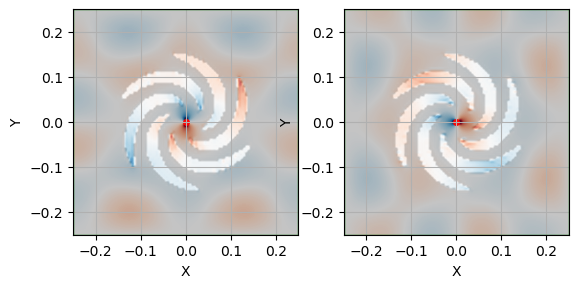

In [4]:
import meep as mp
import numpy as np
import matplotlib.pyplot as plt

# Parameters for the flower shape (from your polar plot)
rmin = 0.04
rmax = 0.1536
rm = (rmax + rmin) / 2
c = rmax - rm + 1e-16
alpha = 18
beta = 0.004
s = 5
Nf = 6  # Number of petals (6-fold symmetry)

# Function to check if a point (x, y) is inside the flower
def is_inside_flower(x, y):
    # Convert to polar coordinates
    r = np.sqrt(x**2 + y**2)
    theta = np.arctan2(y, x)
    if theta < 0:
        theta += 2 * np.pi  # Ensure theta is in [0, 2π]

    # Check if r is within the radial bounds
    if r < rmin or r > rmax:
        return False

    # Compute the angular boundaries for the petal
    rv = r
    theta1 = s * np.sqrt(c**2 - (rv - rm)**2) + alpha * rv + beta * rv**2
    theta2 = -s * np.sqrt(c**2 - (rv - rm)**2) + alpha * rv + beta * rv**2

    # Normalize theta to the first petal and check all petals
    for i in range(Nf):
        dtheta = i * 2 * np.pi / Nf
        # Shift theta to the current petal
        theta_shifted = (theta - dtheta) % (2 * np.pi)
        if theta_shifted < 0:
            theta_shifted += 2 * np.pi

        # Check if theta_shifted is between theta2 and theta1
        # theta2 is the lower bound, theta1 is the upper bound
        if theta2 <= theta_shifted <= theta1:
            return True

    return False

# Meep material function
def flower_material(p):
    x, y = p.x, p.y
    if is_inside_flower(x, y):
        return mp.Medium(epsilon=1)  # Dielectric constant inside flower
    else:
        return mp.Medium(epsilon=12)  # Vacuum outside

# Simulation parameters
cell_size = mp.Vector3(0.5, 0.5, 0)  # 2D simulation (z=0)
resolution = 200  # pixels per unit length
pml_layers = [mp.PML(thickness=0)]  # Perfectly matched layers

# Geometry with custom material
geometry = [
    mp.Block(
        size=cell_size,
        center=mp.Vector3(),
        material=flower_material
    )
]

# Source
sources = [
    mp.Source(
        src=mp.GaussianSource(frequency=1/0.6,fwidth=0.1),
        component=mp.Hz,
        center=mp.Vector3(0, 0)
    )
]

# Simulation setup
sim = mp.Simulation(
    cell_size=cell_size,
    resolution=resolution,
    geometry=geometry,
    sources=sources,
    boundary_layers=pml_layers,
    dimensions=2
)

# Run simulation and visualize dielectric
sim.run(until=5)

# Plot the dielectric constant
#fig, ax = plt.subplots(figsize=(8, 8))
plt.subplot(1,2,1)
sim.plot2D(fields=mp.Ex)
plt.grid()
plt.subplot(1,2,2)
sim.plot2D(fields=mp.Ey)
plt.grid()
plt.savefig("meep_flower_dielectric.png")